In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/raw/harvard/data/reference/dataTable.SUBJECT.csv")

In [43]:
# top_subjects = df[df["E03PASKR"].isin([3])][["E03SUBJECTID", "E03PASKR"]]
# top_subjects = df[df["E03PASKL"].isin([3])][["E03SUBJECTID", "E03PASKL"]]
top_subjects = df[df["E03RADRPAKKL"].isin([3, 4])][["E03SUBJECTID", "E03RADRPAKKL"]]
# top_subjects = df[df["E03RADLPAKKL"].isin([3, 4])][["E03SUBJECTID", "E03RADLPAKKL"]]


print(top_subjects)

                             E03SUBJECTID  E03RADRPAKKL
0    72bb0a51-f020-11ed-b527-0a580a5f736a             3
37   72bb104b-f020-11ed-b527-0a580a5f736a             3
42   72bb1098-f020-11ed-b527-0a580a5f736a             3
43   72bb10a6-f020-11ed-b527-0a580a5f736a             4
52   72bb11b7-f020-11ed-b527-0a580a5f736a             4
..                                    ...           ...
863  e6803cc2-0be0-11ef-91e0-0a580a5f582c             3
865  e6803d70-0be0-11ef-91e0-0a580a5f582c             3
866  e6803d85-0be0-11ef-91e0-0a580a5f582c             3
873  e6803ed7-0be0-11ef-91e0-0a580a5f582c             4
878  e6803faa-0be0-11ef-91e0-0a580a5f582c             3

[152 rows x 2 columns]


In [44]:
top_subjects["E03SUBJECTID"]


0      72bb0a51-f020-11ed-b527-0a580a5f736a
37     72bb104b-f020-11ed-b527-0a580a5f736a
42     72bb1098-f020-11ed-b527-0a580a5f736a
43     72bb10a6-f020-11ed-b527-0a580a5f736a
52     72bb11b7-f020-11ed-b527-0a580a5f736a
                       ...                 
863    e6803cc2-0be0-11ef-91e0-0a580a5f582c
865    e6803d70-0be0-11ef-91e0-0a580a5f582c
866    e6803d85-0be0-11ef-91e0-0a580a5f582c
873    e6803ed7-0be0-11ef-91e0-0a580a5f582c
878    e6803faa-0be0-11ef-91e0-0a580a5f582c
Name: E03SUBJECTID, Length: 152, dtype: object

../data/raw/harvard/data/image/ultrasound/R-post-trans-17/72bb0a51-f020-11ed-b527-0a580a5f736a_17.png
../data/raw/harvard/data/image/ultrasound/R-post-trans-17/72bb104b-f020-11ed-b527-0a580a5f736a_17.png
../data/raw/harvard/data/image/ultrasound/R-post-trans-17/72bb1098-f020-11ed-b527-0a580a5f736a_17.png
../data/raw/harvard/data/image/ultrasound/R-post-trans-17/72bb10a6-f020-11ed-b527-0a580a5f736a_17.png
../data/raw/harvard/data/image/ultrasound/R-post-trans-17/72bb11b7-f020-11ed-b527-0a580a5f736a_17.png
../data/raw/harvard/data/image/ultrasound/R-post-trans-17/72bb1252-f020-11ed-b527-0a580a5f736a_17.png
../data/raw/harvard/data/image/ultrasound/R-post-trans-17/72bb12b4-f020-11ed-b527-0a580a5f736a_17.png
../data/raw/harvard/data/image/ultrasound/R-post-trans-17/72bb12d3-f020-11ed-b527-0a580a5f736a_17.png
../data/raw/harvard/data/image/ultrasound/R-post-trans-17/72bb14c5-f020-11ed-b527-0a580a5f736a_17.png
../data/raw/harvard/data/image/ultrasound/R-post-trans-17/72bb15af-f020-11ed-b527-

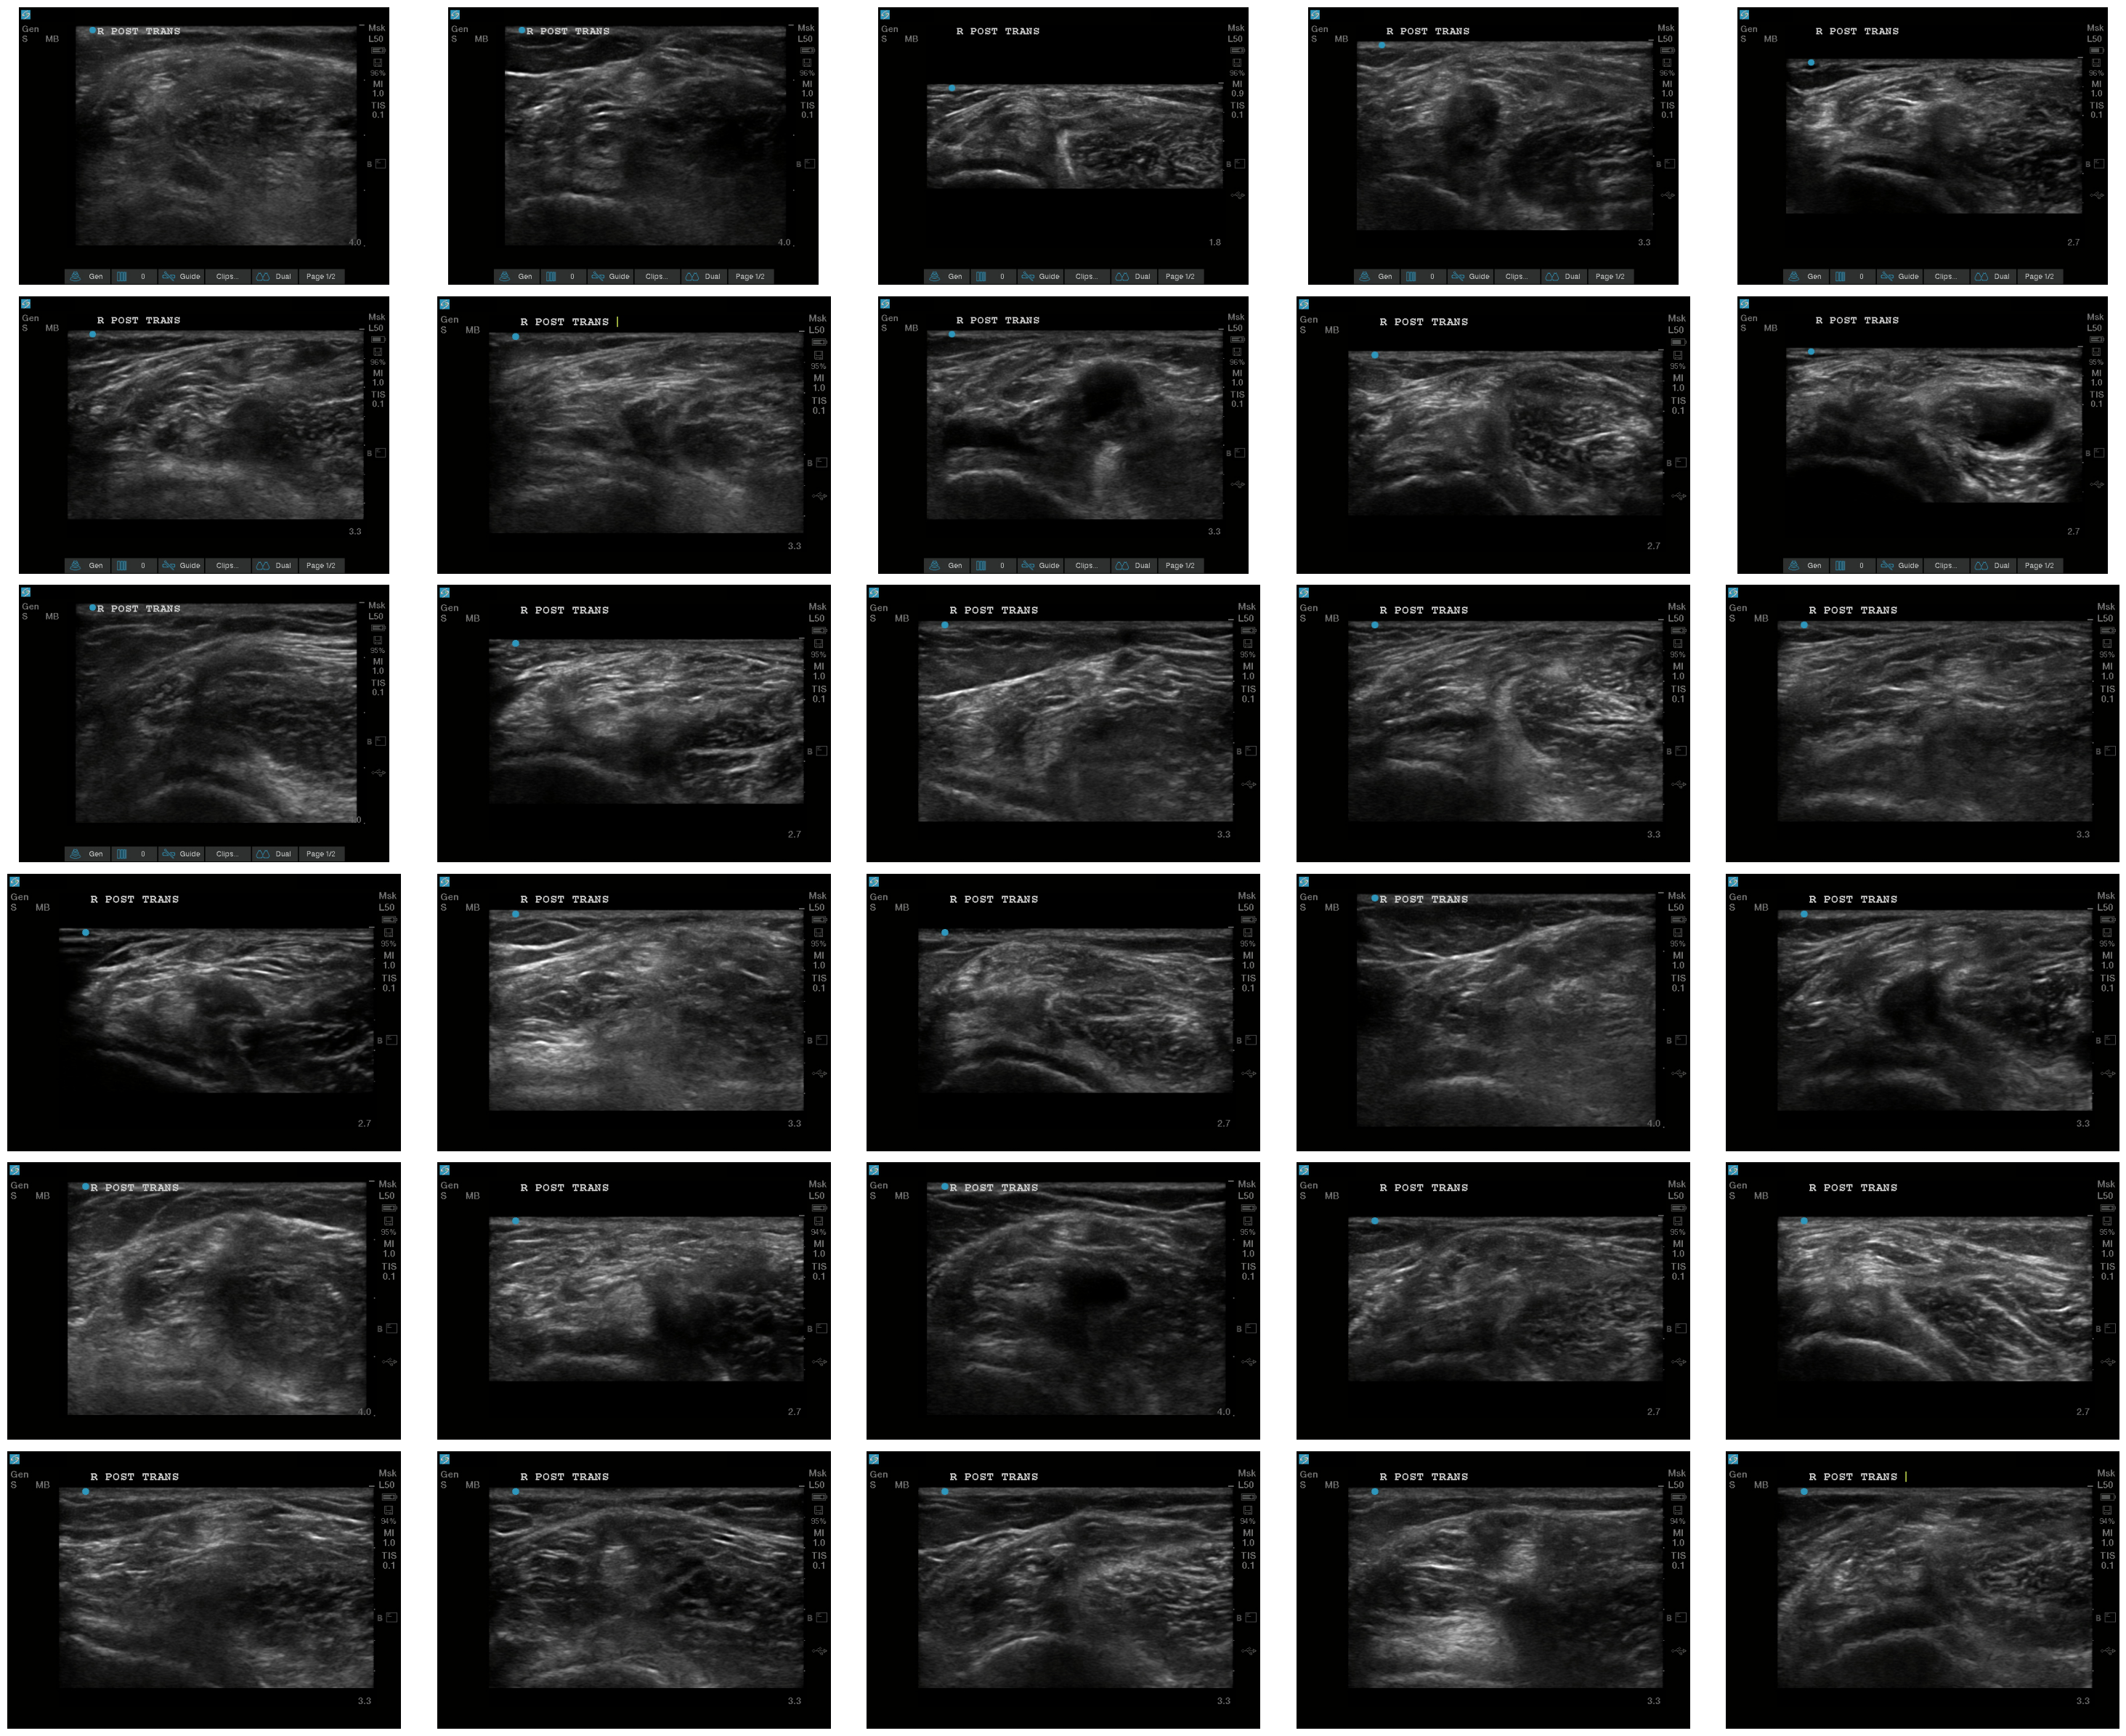

In [45]:
import os

image_dirs = [
    # "../data/raw/harvard/data/image/ultrasound/L-post-trans-27",
    "../data/raw/harvard/data/image/ultrasound/R-post-trans-17"
]
result_paths = []

# Collect up to 15 valid image paths
for image_dir in image_dirs:
    for subject in top_subjects["E03SUBJECTID"]:
        image_path = f"{image_dir}/{subject}_{image_dir[-2:]}.png"
        if os.path.exists(image_path):
            result_paths.append((image_path, subject))
        if len(result_paths) >= 30:
            break
    if len(result_paths) >= 30:
        break

# Plot in a 3x5 grid
fig, axes = plt.subplots(6, 5, figsize=(30, 24))
axes = axes.flatten()

for ax, (image_path, subject) in zip(axes, result_paths):
    print(image_path)
    img = plt.imread(image_path)
    ax.imshow(img, cmap="gray")
    # ax.set_title(f"Subject {subject}")
    ax.axis("off")

# Hide unused subplots
for ax in axes[len(result_paths):]:
    ax.axis("off")

plt.tight_layout()
plt.show()